# The Sportsbook-Playoffs trade — a quantitative teardown 🔬
### The run-up event study · a right-tail random-calendar placebo · the NFL-vs-NCAA split · beta-adjusted and basket/ETF cross-checks · the [−10..+5] anatomy and its look-elsewhere caveat · a costed run-up timer · a 20-seed synthetic null

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Rally%3F: Busted](https://img.shields.io/badge/Rally%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The claim — betting stocks rally *into* the NFL playoffs and March Madness — rests on a genuinely real premise (handle seasonality) and a strong-form-efficiency-tempting mechanism (price the known catalyst ahead). The job here is to measure the pre-season run-up honestly on DraftKings' full public tape, then ask the only question that pays: *is any of it real, and if so, tradable?*

> ⚠️ **Data note.** DKNG + PENN/CZR/MGM/RSI + BETZ + SPY total-return closes (2020→2026), yfinance, cached; **DKNG floored at its 2020-04-24 SPAC-merger close** (earlier tape = DEAC cash shell). **12 hardcoded betting-season starts** (6 NFL + 6 NCAA, 2021→2026). **Survivorship named** on the basket (current survivors of the 2021-22 shakeout — a bias that points *for* the rally). Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md) (fingerprints `72bd1b0f5d55` DKNG / `5438abdf1003` BETZ / `c33b73c750b6` SPY).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from sportsbook_playoffs import data, strategy as st

EVENTS = data.event_table()
RUN_UP = 10
HAVE_REAL = data.have_real()
if HAVE_REAL:
    CLOSES = data.load_real()
    DKNG = CLOSES["DKNG"]
    RET = st.daily_returns(DKNG)
    AR = st.abnormal_returns(RET)
    BENCH_RET = st.daily_returns(CLOSES["SPY"])
    AR_MADJ = st.abnormal_returns(st.market_adjusted_returns(RET, BENCH_RET))
    BASKET, COVERAGE = st.basket_returns(CLOSES, data.BASKET_TICKERS)
    AR_BASKET = st.abnormal_returns(BASKET)
    AR_BETZ = st.abnormal_returns(st.daily_returns(CLOSES["BETZ"]))
else:
    CLOSES = DKNG = RET = AR = AR_MADJ = BASKET = COVERAGE = AR_BASKET = AR_BETZ = None
print("real cache present:", HAVE_REAL, "| betting seasons in table:", len(EVENTS))

# frozen headline numbers (mirror of docs/results.md)
R = {'n': 12, 'cal_lo': '2021-01-09', 'cal_hi': '2026-03-19', 'run_up': 10, 'run_up_pct': -1.93, 'run_up_t': -0.55, 'hits': 5, 'hit_n': 12, 'hit_pct': 41.7, 'wilson': (19.3, 68.0), 'boot': (-8.37, 4.63), 'placebo_mean_pct': -0.038, 'placebo_sd_pct': 3.59, 'placebo_p': 0.698, 'placebo_draws': 20000, 'nfl': (-0.76, -0.14, 6, 3), 'ncaa': (-3.1, -0.63, 6, 2), 'welch': 0.32, 'madj_mean': -1.28, 'madj_t': -0.41, 'basket_mean': -3.24, 'basket_t': -1.19, 'basket_hits': 3, 'basket_wilson': (8.9, 53.2), 'betz_mean': -1.24, 'betz_t': -0.74, 'betz_hits': 4, 'post_mean': -2.8, 'post_t': -1.03, 'event': {-10: (-171.7, -171.7, -1.54), -9: (-193.8, -365.5, -2.76), -8: (-207.4, -572.9, -1.45), -7: (156.7, -416.2, 1.41), -6: (91.4, -324.8, 1.14), -5: (-73.3, -398.1, -0.88), -4: (-8.9, -407.0, -0.07), -3: (-52.1, -459.1, -0.61), -2: (91.5, -367.7, 0.82), -1: (174.2, -193.4, 1.19), 0: (127.7, -65.8, 1.54), 1: (-77.9, -143.7, -0.93), 2: (-61.1, -204.8, -0.61), 3: (34.8, -169.9, 0.32), 4: (-245.5, -415.5, -2.09), 5: (-58.2, -473.7, -0.72)}, 'timer': {5: (245.9, 235.9, 215.9, 0.87, 50), 10: (52.2, 42.2, 22.2, 0.07, 42), 20: (-178.2, -188.2, -208.2, -0.54, 58)}, 'syn_null_mean': 0.14, 'syn_null_sd': 0.63, 'syn_null_fire': 0, 'syn_planted_mean': 14.2, 'syn_planted_t': 4.37, 'fp_dkng': '72bd1b0f5d55', 'fp_penn': 'e888bef384fc', 'fp_czr': '48824d07b05a', 'fp_mgm': '9ca308e4bd97', 'fp_rsi': '793daf5af45c', 'fp_betz': '5438abdf1003', 'fp_spy': 'c33b73c750b6'}


real cache present: True | betting seasons in table: 12


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | run-up CAR **-1.93%** (wrong sign), one-sample **t = -0.55**, hit rate 41.7% (Wilson [19.3%, 68.0%]), placebo (right-tail) **p = 0.698** |
| **Tradability** | `MIRAGE` | run-up timer nets **+22.2 bps** at 10d (t = 0.07); the only positive leg (5d, +216 bps) is t = 0.87, 50% win, and flips sign by 20d |
| **Rally into the season?** | `BUSTED` | basket **-1.19**, BETZ **-0.74**, market-adj **-0.41** — every cross-check agrees the pre-season drift is *down*, not up |

> 💡 In plain words: the betting-handle seasonality is real, but the stock-price rally folklore attaches to it isn't — every way we slice the run-up, it comes back negative and insignificant.

## 1 · The claim, steelmanned

Let $r_t$ be DKNG's daily total-return and $a_t = r_t - \bar{r}$ its abnormal return under a constant-mean market model (Brown & Warner 1985). For each betting season $i$ with public first-game date $\tau_i$, snapped to the first session on/after it, define the **run-up** $U_i = \sum_{k=1}^{K} a_{\tau_i - k}$ over the $K=10$ sessions before the games. The claims:

- **H₁ (pre-season rally).** $E[U_i] > 0$, large and systematic across events — the stocks price the coming handle ahead of tip-off.
- **H₂ (sector-wide).** The same holds for a betting basket and the BETZ ETF, not just DKNG.
- **H₃ (not just beta).** The run-up survives subtracting the market's return over the same window.
- **H₄ (capture).** A buy-the-run-up overlay beats zero net of costs.

We find **H₁ rejected on sign** (run-up -1.93%, t = -0.55 — *negative*), **H₂ rejected** (basket t = -1.19, BETZ t = -0.74, both negative), **H₃ moot** (market-adj t = -0.41, still negative), **H₄ not supported** (no cost-surviving edge at any horizon).

## 2 · So what? — inference design

Betting seasons are **independent, non-overlapping calendar dates** (the closest pair — a January NFL and the following March — is ~9 weeks apart, and the run-up windows never overlap), so the planned primary is a **one-sample t-test** across the 12 per-event run-up figures — the correct unit of analysis is "one run-up per season", not a daily panel, so no HAC correction is needed the way a daily regression would require. The hit rate carries a **Wilson interval**; the placebo draws 12 random dates **20,000 times (20 seeds × 1,000)** and is read on the **right tail** because the claim predicts a *positive* run-up; the [−10..+5] anatomy is read as a **16-offset multiple-comparison** exercise, not 16 independent shots. Because the season-start dates are **public months ahead**, the entry/exit sessions are known ex-ante — a **calendar-known rule with zero look-ahead and no execution lag**, applied once and documented once.

## 3 · How we'd know — the protocol

- **Calendar.** 12 flagship betting-season starts 2021-01-09 → 2026-03-19, hardcoded (6 NFL Wild-Card weekends + 6 March-Madness Round-of-64s). All 12 sit on the DKNG tape.
- **Tape.** DKNG (from its 2020-04-24 merger close) + PENN/CZR/MGM/RSI + BETZ + SPY total-return closes, → 2026-06-30 (as-of, last complete month).
- **Headline.** Run-up CAR over the 10 sessions before the first game, one-sample t + Wilson hit rate + 20-seed right-tail placebo + event-bootstrap CI.
- **Splits.** NFL vs NCAA one-sample t's and a Welch t of the difference.
- **Cross-checks.** The 5-name basket, the BETZ ETF, and a beta≈1 market-adjusted (DKNG − SPY) run-up.
- **Anatomy.** Event window [−10..+5], per-offset mean + t, read with the multiple-comparison caveat; a post-event [0..+5] sell-the-news test.
- **Execution (timer).** Buy DKNG N sessions before the first game, sell the session before it (zero look-ahead — schedule public); 2 × one-way cost × NAV per event; long-only.
- **Control.** Synthetic random-walk tape, planted pre-event run-up; the null must not fire across 20 seeds.

## 4 · The teardown

### 4a · The headline run-up and its right-tail placebo

One-sample t on the 10-day run-up CAR, Wilson hit rate, and the random-calendar null. In the notebook we run a lighter placebo (4 seeds × 500 draws) and quote the canonical 20,000-draw p from `results.md`.

run-up CAR -1.93%  one-sample t = -0.552  (n=12)
hit rate: 5/12 = 41.7% positive  (Wilson [19.3%, 68.0%])


event-bootstrap 95% CI on the mean run-up: [-8.37%, +4.63%]


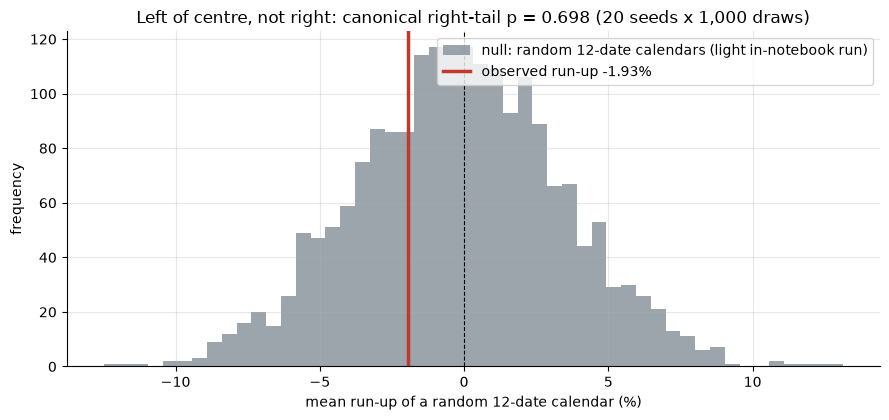

canonical placebo (results.md): mean -0.038%, sd 3.59%, right-tail p = 0.698


In [2]:
if HAVE_REAL:
    r = st.run_up_stats(AR, EVENTS['date'], run_up=RUN_UP)
    wl, wh = st.wilson_interval(r['hits'], r['n'])
    print(f"run-up CAR {r['mean']*100:+.2f}%  one-sample t = {r['t']:+.3f}  (n={r['n']})")
    print(f"hit rate: {r['hits']}/{r['n']} = {r['hits']/r['n']*100:.1f}% positive  "
          f"(Wilson [{wl*100:.1f}%, {wh*100:.1f}%])")
    lo, hi = st.bootstrap_ci(r['per_event'])
    print(f"event-bootstrap 95% CI on the mean run-up: [{lo*100:+.2f}%, {hi*100:+.2f}%]")
    pl = np.concatenate([st.placebo_distribution(AR, r['n'], run_up=RUN_UP,
                          n_draws=500, seed=736 + s_) for s_ in range(4)])
    obs, draws = r['mean'], pl
else:
    obs = R['run_up_pct'] / 100
    rng = np.random.default_rng(736)
    draws = rng.normal(R['placebo_mean_pct'] / 100, R['placebo_sd_pct'] / 100, 2000)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(draws * 100, bins=50, color=GREY, alpha=.85,
        label='null: random 12-date calendars (light in-notebook run)')
ax.axvline(obs * 100, c=RED, lw=2.5, label=f'observed run-up {obs*100:+.2f}%')
ax.axvline(0, c='k', lw=.8, ls='--')
ax.set_xlabel('mean run-up of a random 12-date calendar (%)')
ax.set_ylabel('frequency')
ax.set_title(f"Left of centre, not right: canonical right-tail p = {R['placebo_p']:.3f} "
             '(20 seeds x 1,000 draws)')
ax.legend(); plt.tight_layout(); plt.show()
print(f"canonical placebo (results.md): mean {R['placebo_mean_pct']:+.3f}%, "
      f"sd {R['placebo_sd_pct']:.2f}%, right-tail p = {R['placebo_p']:.3f}")

> 💡 In plain words: the observed run-up **-1.93%** sits *below* the centre of the null cloud (-0.038 ± 3.59%). The right-tail **p = 0.698** means a random calendar produces a run-up this big or bigger ~70% of the time. With one-sample t = **-0.55** and a bootstrap CI [-8.37%, +4.63%] straddling zero, H₁ is rejected — and on the *wrong side*.

### 4b · The season split and the sector/beta cross-checks

If a rally hides in one season, or in the wider sector, or is just market beta, this is where it shows up. It doesn't.

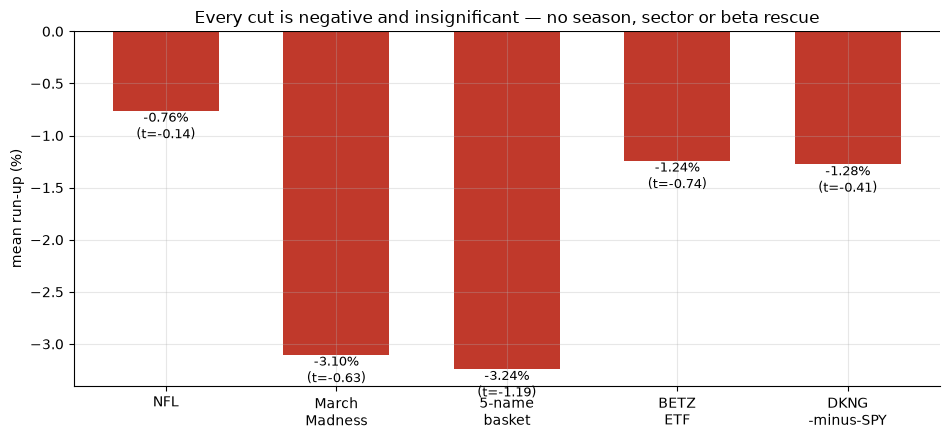

run-ups (%): {'NFL': -0.76, 'March Madness': -3.1, '5-name basket': -3.24, 'BETZ ETF': -1.24, 'DKNG -minus-SPY': -1.28}
Welch t (NFL - NCAA) = +0.32


In [3]:
if HAVE_REAL:
    nfl = st.run_up_stats(AR, EVENTS[EVENTS['family']=='NFL']['date'], run_up=RUN_UP)
    ncaa = st.run_up_stats(AR, EVENTS[EVENTS['family']=='NCAA']['date'], run_up=RUN_UP)
    rb = st.run_up_stats(AR_BASKET, EVENTS['date'], run_up=RUN_UP)
    re = st.run_up_stats(AR_BETZ, EVENTS['date'], run_up=RUN_UP)
    rm = st.run_up_stats(AR_MADJ, EVENTS['date'], run_up=RUN_UP)
    welch = st.welch_t(nfl['per_event'], ncaa['per_event'])
    labels = ['NFL', 'March\nMadness', '5-name\nbasket', 'BETZ\nETF', 'DKNG\n-minus-SPY']
    vals = [nfl['mean']*100, ncaa['mean']*100, rb['mean']*100, re['mean']*100, rm['mean']*100]
    ts = [nfl['t'], ncaa['t'], rb['t'], re['t'], rm['t']]
else:
    welch = R['welch']
    labels = ['NFL', 'March\nMadness', '5-name\nbasket', 'BETZ\nETF', 'DKNG\n-minus-SPY']
    vals = [R['nfl'][0], R['ncaa'][0], R['basket_mean'], R['betz_mean'], R['madj_mean']]
    ts = [R['nfl'][1], R['ncaa'][1], R['basket_t'], R['betz_t'], R['madj_t']]
fig, ax = plt.subplots(figsize=(9.6, 4.5))
ax.bar(labels, vals, color=[RED]*len(vals), width=.62)
for i, (v, t) in enumerate(zip(vals, ts)):
    ax.annotate(f'{v:+.2f}%\n(t={t:+.2f})', (i, v), ha='center', va='top', fontsize=9)
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('mean run-up (%)')
ax.set_title('Every cut is negative and insignificant — no season, sector or beta rescue')
plt.tight_layout(); plt.show()
print('run-ups (%):', dict(zip([l.replace(chr(10),' ') for l in labels], [round(v,2) for v in vals])))
print(f'Welch t (NFL - NCAA) = {welch:+.2f}')

> 💡 In plain words: NFL (-0.76%, t = -0.14) and March Madness (-3.10%, t = -0.63) are the same nothing (Welch t = +0.32); the 5-name basket (-3.24%, t = -1.19) and BETZ (-1.24%, t = -0.74) drift down too; and subtracting the market (DKNG − SPY, -1.28%, t = -0.41) doesn't turn it positive. H₂ and H₃ both fail.

### 4c · Anatomy — the [−10..+5] window, read with the multiple-comparison caveat

Per-offset means with each offset's own one-sample t. With 16 offsets tested, ~0.8 crossing |t| ≥ 2 by pure chance at the 5% level is expected — exactly two do (offsets −9 and +4), and **both are negative**, pointing the wrong way for a rally and attached to no mechanism.

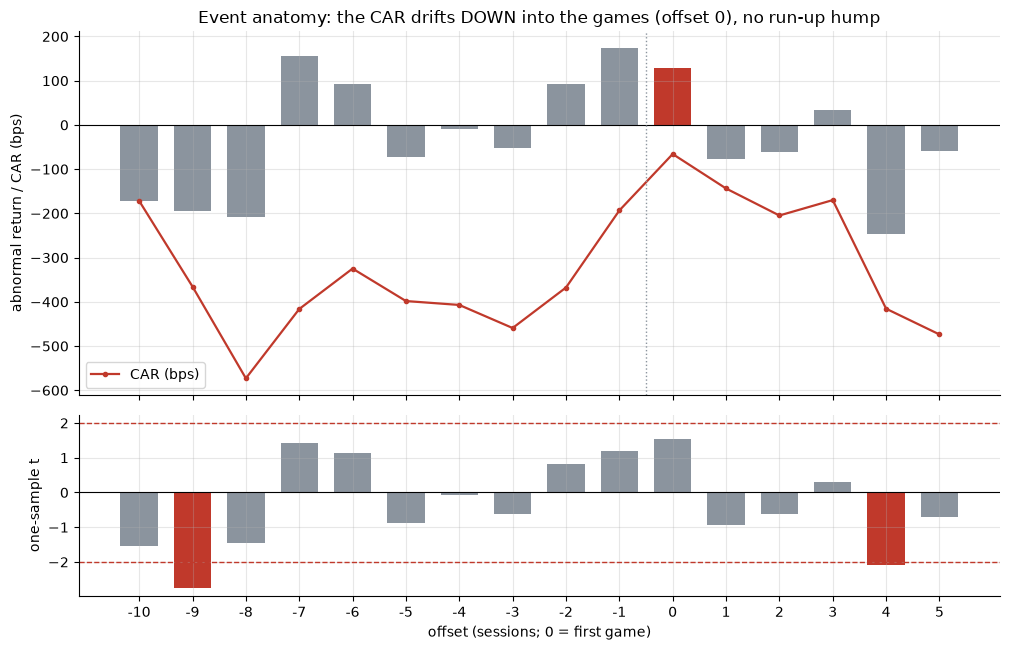

post-game [0..+5] sell-the-news test: -2.80% (t = -1.03)


In [4]:
if HAVE_REAL:
    cp = st.car_path_stats(AR, EVENTS['date'], pre=RUN_UP, post=5)
    ks = list(cp.index); ms = list(cp['mean_ar'] * 1e4); ts = list(cp['t'])
    cars = list(cp['car'] * 1e4)
    pe = st.post_event_stats(AR, EVENTS['date'], pre=RUN_UP, post=5)
    post_m, post_t = pe['mean']*100, pe['t']
else:
    ks = sorted(R['event']); ms = [R['event'][k][0] for k in ks]
    cars = [R['event'][k][1] for k in ks]; ts = [R['event'][k][2] for k in ks]
    post_m, post_t = R['post_mean'], R['post_t']
fig, (a1, a2) = plt.subplots(2, 1, figsize=(10.2, 6.6), sharex=True,
                             gridspec_kw={'height_ratios': [2, 1]})
cols = [RED if k == 0 else GREY for k in ks]
a1.bar([str(k) for k in ks], ms, color=cols, width=.7)
a1.plot(range(len(ks)), cars, color=RED, lw=1.6, marker='o', ms=3, label='CAR (bps)')
a1.axhline(0, c='k', lw=.8); a1.set_ylabel('abnormal return / CAR (bps)')
a1.axvline(RUN_UP - 0.5, c=GREY, ls=':', lw=1)
a1.set_title('Event anatomy: the CAR drifts DOWN into the games (offset 0), no run-up hump')
a1.legend(loc='lower left')
a2.bar([str(k) for k in ks], ts,
       color=[RED if abs(t) >= 2 else GREY for t in ts], width=.7)
a2.axhline(0, c='k', lw=.8)
a2.axhline(-2, ls='--', c=RED, lw=1); a2.axhline(2, ls='--', c=RED, lw=1)
a2.set_ylabel('one-sample t'); a2.set_xlabel('offset (sessions; 0 = first game)')
plt.tight_layout(); plt.show()
print(f'post-game [0..+5] sell-the-news test: {post_m:+.2f}% (t = {post_t:+.2f})')

> 💡 In plain words: the cumulative abnormal return actually *falls* into the first game (CAR ≈ -193 bps at offset −1) — the opposite of a run-up hump. The two |t| ≥ 2 bars (offset −9 at t = -2.76, offset +4 at t = -2.09) are both *down*, mechanism-free, and exactly the ~1 spurious crossing you expect from 16 offsets. The post-game [0..+5] leg is **-2.80%** (t = -1.03) — no sell-the-news round trip either, because there was no run-up to sell.

### 4d · The timer — an honest "buy the run-up" cost sweep

Buy DKNG at the close N sessions before the first game, sell at the close the session before it (zero look-ahead — the schedule is public months ahead), one round trip of one-way costs charged twice, across the 12 seasons. Gross, net at 5 and 15 bps.

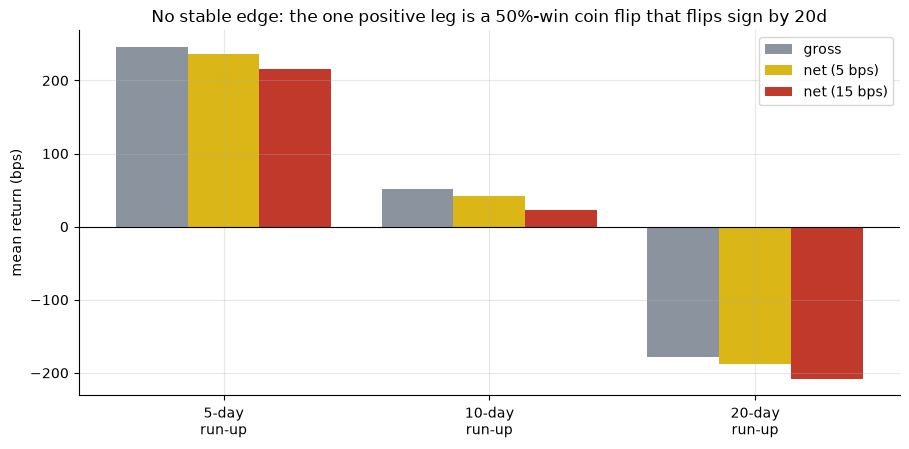

gross (bps): {5: 245.9, 10: 52.2, 20: -178.2}
net 15bps (bps): {5: 215.9, 10: 22.2, 20: -208.2}
t (net15): {5: 0.87, 10: 0.07, 20: -0.54}
win rate (%): {5: 50, 10: 42, 20: 58}


In [5]:
if HAVE_REAL:
    holds = [5, 10, 20]
    gross, net5, net15, tt, win = [], [], [], [], []
    for h in holds:
        g = st.summarize_timer(st.run_up_timer(DKNG, EVENTS['date'], run_up=h, cost_bps=0.0), 'ret_gross')
        n5 = st.summarize_timer(st.run_up_timer(DKNG, EVENTS['date'], run_up=h, cost_bps=5.0), 'ret_net')
        n15 = st.summarize_timer(st.run_up_timer(DKNG, EVENTS['date'], run_up=h, cost_bps=15.0), 'ret_net')
        gross.append(g['mean_bps']); net5.append(n5['mean_bps'])
        net15.append(n15['mean_bps']); tt.append(n15['t']); win.append(g['win_rate']*100)
else:
    holds = [5, 10, 20]
    gross = [R['timer'][h][0] for h in holds]
    net5 = [R['timer'][h][1] for h in holds]
    net15 = [R['timer'][h][2] for h in holds]
    tt = [R['timer'][h][3] for h in holds]; win = [R['timer'][h][4] for h in holds]
fig, ax = plt.subplots(figsize=(9.2, 4.6))
x = np.arange(len(holds)); w = 0.27
ax.bar(x - w, gross, width=w, color=GREY, label='gross')
ax.bar(x, net5, width=w, color=AMBER, label='net (5 bps)')
ax.bar(x + w, net15, width=w, color=RED, label='net (15 bps)')
ax.axhline(0, c='k', lw=.8)
ax.set_xticks(x); ax.set_xticklabels([f'{h}-day\nrun-up' for h in holds])
ax.set_ylabel('mean return (bps)')
ax.set_title('No stable edge: the one positive leg is a 50%-win coin flip that flips sign by 20d')
ax.legend(); plt.tight_layout(); plt.show()
print('gross (bps):', dict(zip(holds, [round(v,1) for v in gross])))
print('net 15bps (bps):', dict(zip(holds, [round(v,1) for v in net15])))
print('t (net15):', dict(zip(holds, [round(t,2) for t in tt])))
print('win rate (%):', dict(zip(holds, [round(w) for w in win])))

> 💡 In plain words: the 5-day run-up nets **+215.9 bps** at 15 bps costs — but on t = 0.87, a 50% win rate across 12 events, it's a coin flip that landed heads. Lengthen the window and it evaporates: 10-day nets **+22.2 bps** (t = 0.07), 20-day **-208.2 bps** (t = -0.54). H₄ is not supported — there is no stable edge, so the cost question is moot.

### 4e · Faithful-engine & power control — we know the truth here

Synthetic random-walk tape, 12 scheduled pseudo-season dates, TUNABLE planted run-up that accumulates over the 10 sessions before each event. The null (bump=0) is checked over **20 seeds** — never a single stream.

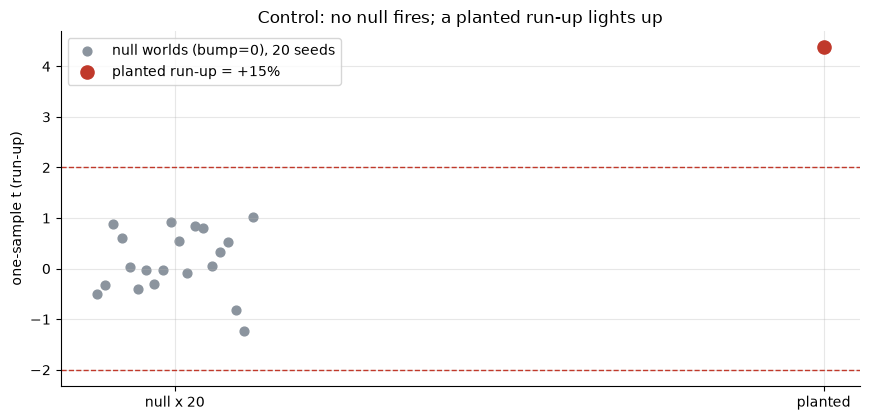

null: mean t = +0.14 (sd 0.63), |t|>=2 in 0/20 seeds  |  planted t = +4.37


In [6]:
null_ts = []
for s_ in range(20):
    close, ev = data.synthetic_world(bump=0.0, seed=736 + s_)
    null_ts.append(st.synthetic_detect(close, ev)['t'])
null_ts = np.asarray(null_ts)
close, ev = data.synthetic_world(bump=0.15, seed=736)
planted_t = st.synthetic_detect(close, ev)['t']
fig, ax = plt.subplots(figsize=(8.8, 4.3))
ax.scatter(np.zeros(20) + np.linspace(-.12, .12, 20), null_ts, color=GREY, s=40,
           label='null worlds (bump=0), 20 seeds')
ax.scatter([1], [planted_t], color=RED, s=90, zorder=5, label='planted run-up = +15%')
ax.axhline(-2, ls='--', c=RED, lw=1); ax.axhline(2, ls='--', c=RED, lw=1)
ax.set_xticks([0, 1]); ax.set_xticklabels(['null x 20', 'planted'])
ax.set_ylabel('one-sample t (run-up)')
ax.set_title('Control: no null fires; a planted run-up lights up')
ax.legend(); plt.tight_layout(); plt.show()
print(f'null: mean t = {null_ts.mean():+.2f} (sd {null_ts.std(ddof=1):.2f}), '
      f'|t|>=2 in {(np.abs(null_ts) >= 2).sum()}/20 seeds  |  planted t = {planted_t:+.2f}')

> 💡 In plain words: across 20 null worlds the detector averages t = +0.14 (sd 0.63) and **never** crosses the bar; a planted +15% run-up reads t = 4.37. The machinery is unbiased — the real-tape t ≈ −0.55 is the genuine, honest reading, not a detector asleep at the wheel. *(A faithful-engine / power check only — never cited in support of the real-tape stamp.)*

## 5 · The verdict

- **Signal `NONE`** — run-up CAR **-1.93%** (wrong sign), one-sample t = **-0.55**, hit rate 41.7% (Wilson [19.3%, 68.0%]), right-tail placebo p = **0.698**. The basket (t = -1.19), BETZ (t = -0.74) and market-adjusted (t = -0.41) cross-checks all agree; neither season rescues it. The two |t| ≥ 2 offsets (−9, +4) are look-elsewhere artifacts among 16 offsets — and both negative.
- **Tradability `MIRAGE`** — the run-up timer nets +22.2 bps at 10d (t = 0.07); the one positive leg (5d, +216 bps) is t = 0.87, 50% win, and flips sign by 20d. No stable edge to charge costs against.
- **"Do betting stocks rally into the season?" `BUSTED`** — the handle seasonality is real (Beat 2's labelled proxy), but the tradable stock-price rally is not: on DraftKings' full public tape the stocks drift *down* into the games. A schedule everyone can read a year ahead is already in the price.

## 6 · Going further

- **Efficiency is the honest explanation.** The betting calendar is maximally public, so an easy pre-season rally would have been arbitraged into earlier weeks (or the prior off-season) long ago. A null here is what an efficient market *should* deliver on a fully-anticipated catalyst.
- **The surprise version is a different study.** Test the *unexpected* component — a record-shattering handle vs. a merely-typical season, measured against analyst expectations, or the earnings prints that report the handle weeks later — a fundamentals event study, not a calendar one.
- **Power is a real limit.** n=12 seasons over ~6 years of DKNG history is small; a tiny real seasonal tilt could be invisible. The honest conclusion is "not detectable, wrong sign, at this size on this tape."
- **Dedup map:** [707-plane-crash-effect](../../707-plane-crash-effect/) and [708-eurovision-effect](../../708-eurovision-effect/) share this exact event-study machinery on other folklore; [300-sports-sentiment](../../300-sports-sentiment/) tests sports *results* on the *home* market. None test whether the betting stocks themselves rally into the betting calendar — that scheduled-anticipation axis is this study's own.

*The reproducible core is offline and deterministic; frozen numbers live in [`docs/results.md`](../docs/results.md), sources in [`docs/references.md`](../docs/references.md).*